# Incremental Capstone — Session 4
## Data Visualization Techniques

This notebook builds on the cleaned and analyzed NSMES1988 healthcare dataset from the previous capstone sessions.

The objective of Session 4 is to use Python visualization techniques to present important patterns in healthcare utilization, demographic characteristics, income, health status, geographic region, and correlations among numerical variables.

## 1. Import Required Libraries

In [1]:
# Import Pandas for data manipulation and analysis.
import pandas as pd

# Import NumPy for numerical operations.
import numpy as np

# Import Matplotlib for data visualization.
import matplotlib.pyplot as plt

## 2. Import the Updated Dataset

The `NSMES1988updated.csv` dataset created during the previous capstone sessions will be imported into a new Pandas DataFrame.

This dataset already contains the corrected age and income values from the earlier preprocessing work, so those variables do not need to be transformed again.

In [2]:
# Load the updated healthcare dataset into a Pandas DataFrame.
df = pd.read_csv("../data/NSMES1988updated.csv")

# Display the first five rows to verify that the file loaded correctly.
df.head()

,visits,nvisits,ovisits,novisits,emergency,hospital,health,chronic,adl,region,age,gender,married,school,income,employed,insurance,medicaid
0,5,0,0,0,0,1,average,2,normal,other,69.0,male,yes,6,28810.0,yes,yes,no
1,1,0,2,0,2,0,average,2,normal,other,74.0,female,yes,10,27478.0,no,yes,no
2,13,0,0,0,3,3,poor,4,limited,other,66.0,female,no,10,6532.0,no,no,yes
3,16,0,5,0,1,1,poor,2,limited,other,76.0,male,yes,3,6588.0,no,yes,no
4,3,0,0,0,0,0,average,2,limited,other,79.0,female,yes,6,6588.0,no,yes,no


## 3. Verify the Dataset

Before creating visualizations, the dataset will be inspected to confirm its dimensions, data types, and missing-value status.

This verification ensures that the updated dataset loaded correctly and remains consistent with the dataset prepared during the previous capstone sessions.

In [3]:
# Display the number of rows and columns in the dataset.
print("Dataset Shape:", df.shape)

# Display column names and data types,
# non-null counts, and memory information.
print("\nDataset Information:")
df.info()

# Count missing values in each column.
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (4406, 18)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     4406 non-null   int64  
 1   nvisits    4406 non-null   int64  
 2   ovisits    4406 non-null   int64  
 3   novisits   4406 non-null   int64  
 4   emergency  4406 non-null   int64  
 5   hospital   4406 non-null   int64  
 6   health     4406 non-null   str    
 7   chronic    4406 non-null   int64  
 8   adl        4406 non-null   str    
 9   region     4406 non-null   str    
 10  age        4406 non-null   float64
 11  gender     4406 non-null   str    
 12  married    4406 non-null   str    
 13  school     4406 non-null   int64  
 14  income     4406 non-null   float64
 15  employed   4406 non-null   str    
 16  insurance  4406 non-null   str    
 17  medicaid   4406 non-null   str    
dtypes: float64(2), int64(8), str(8)
memory usage: 619.7

### Dataset Verification Findings

The updated dataset contains 4,406 observations and 18 variables, which is consistent with the dataset prepared during the previous capstone sessions.

All 18 variables contain 4,406 non-null observations, indicating that there are no missing values in the dataset.

The dataset contains numerical variables representing healthcare utilization, chronic conditions, age, education, and income, as well as categorical variables representing health status, activities of daily living, region, gender, marital status, employment, insurance, and Medicaid coverage.

The age and income variables contain the corrected values created during the earlier preprocessing work. No additional scaling or transformation is required before visualization.

## 4. Plotting Library Choice

Matplotlib was selected as the primary visualization library for this analysis.

Matplotlib is a widely used Python visualization library that integrates well with Pandas and provides control over chart titles, axis labels, legends, figure sizes, and other presentation elements. It supports the bar charts, line charts, and correlation visualizations needed for this project.

Using Matplotlib also allows the visualizations to be customized so that the results of the healthcare analysis can be presented clearly and consistently.

## 5. Health Status by Region

The distribution of self-reported health status across geographic regions will be visualized using a grouped bar chart.

A grouped bar chart allows the number of individuals reporting average, excellent, and poor health to be compared across the four regions represented in the dataset.

In [4]:
# Create a cross-tabulation containing the number of individuals
# in each Health Status and Region combination.
health_region_counts = pd.crosstab(
    df["health"],
    df["region"]
)

# Give the rows and columns descriptive labels.
health_region_counts.index.name = "Health Status"
health_region_counts.columns.name = "Region"

# Display the table used to create the visualization.
health_region_counts

Region,midwest,northeast,other,west
Health Status,,,,
average,957,694,1237,621
excellent,90,57,105,91
poor,110,86,272,86


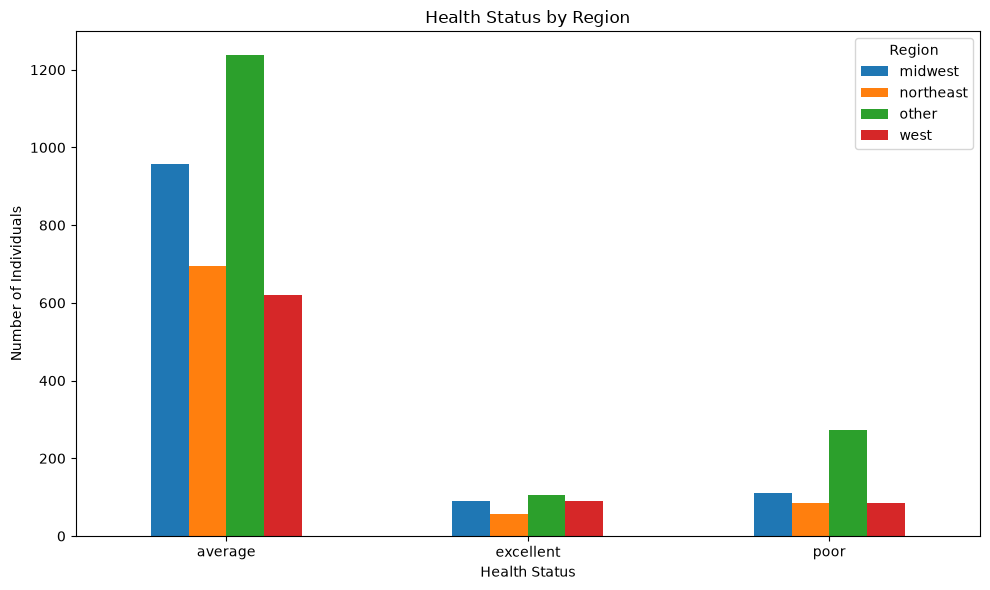

In [5]:
# Create a grouped bar chart from the Health x Region count table.
health_region_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add a descriptive chart title and axis labels.
plt.title("Health Status by Region")
plt.xlabel("Health Status")
plt.ylabel("Number of Individuals")

# Keep the health-status labels horizontal for readability.
plt.xticks(rotation=0)

# Add a descriptive title to the legend.
plt.legend(title="Region")

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Health Status by Region Visualization Findings

The grouped bar chart shows that average health is the most frequently reported health status in every geographic region.

The Other region contains the largest number of individuals reporting average health and poor health. It also contains the largest raw number of observations overall. Excellent health has the smallest number of observations in most regions.

The differences shown in this visualization represent raw counts rather than percentages. Because the total number of individuals differs across regions, the chart should not be interpreted as evidence that one region has better or worse health solely based on the height of the bars.

Overall, the visualization confirms the Session 3 finding that average health is the dominant self-reported health category across all four regions.

## 6. Average Healthcare Visits by Health and Region

Average healthcare visits will be compared across self-reported health status and geographic region.

A grouped bar chart will be used to visualize whether individuals reporting average, excellent, or poor health show different levels of healthcare utilization across the four regions.

In [6]:
# Create a pivot table calculating the average number
# of healthcare visits for each Health Status and Region combination.
health_region_visits = pd.pivot_table(
    df,
    index="health",
    columns="region",
    values="visits",
    aggfunc="mean"
)

# Give the rows and columns descriptive labels.
health_region_visits.index.name = "Health Status"
health_region_visits.columns.name = "Region"

# Display the averages rounded to two decimal places.
health_region_visits.style.format("{:,.2f}")

Region,midwest,northeast,other,west
Health Status,,,,
average,5.28,5.69,5.09,6.50
excellent,3.44,4.02,3.14,3.37
poor,8.12,10.67,8.75,8.59


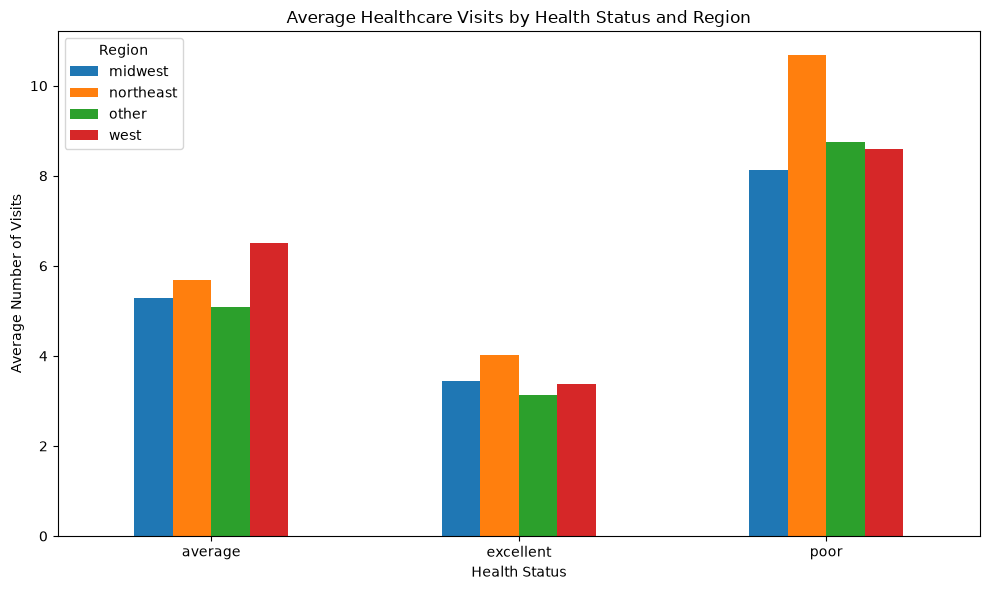

In [7]:
# Create a grouped bar chart showing average healthcare visits
# for each Health Status and Region combination.
health_region_visits.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add a descriptive title and axis labels.
plt.title("Average Healthcare Visits by Health Status and Region")
plt.xlabel("Health Status")
plt.ylabel("Average Number of Visits")

# Keep the health-status labels horizontal for readability.
plt.xticks(rotation=0)

# Add a descriptive title to the legend.
plt.legend(title="Region")

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Average Healthcare Visits by Health and Region Findings

The visualization shows a consistent relationship between self-reported health status and average healthcare utilization across all four geographic regions.

Individuals reporting poor health have the highest average number of healthcare visits in every region. The Northeast has the highest average utilization among individuals reporting poor health at 10.67 visits, followed by the Other region at 8.75, the West at 8.59, and the Midwest at 8.12.

Individuals reporting excellent health have the lowest average healthcare utilization in every region, ranging from 3.14 visits in the Other region to 4.02 visits in the Northeast. Individuals reporting average health fall between the excellent and poor health groups.

Overall, the visualization reinforces the Session 3 finding that poorer self-reported health is associated with greater healthcare utilization across geographic regions. The chart shows an association within the dataset and does not establish that health status directly causes the differences in healthcare utilization.

## 7. Healthcare Utilization by Gender

Average healthcare utilization will be compared between female and male individuals across the six healthcare visit measures.

A grouped bar chart will be used to show whether utilization patterns differ by gender for overall visits, nvisits, ovisits, novisits, emergency visits, and hospital visits.

In [8]:
# Define the healthcare utilization variables that will be analyzed.
visit_columns = [
    "visits",
    "nvisits",
    "ovisits",
    "novisits",
    "emergency",
    "hospital"
]

# Group the dataset by gender and calculate the
# average for each healthcare utilization variable.
visits_by_gender = df.groupby("gender")[visit_columns].mean()

# Give the row index a descriptive label.
visits_by_gender.index.name = "Gender"

# Rename the columns for a cleaner presentation.
visits_by_gender.columns = [
    "Visits",
    "Nvisits",
    "Ovisits",
    "Novisits",
    "Emergency",
    "Hospital"
]

# Display the averages rounded to two decimal places.
visits_by_gender.style.format("{:,.2f}")

,Visits,Nvisits,Ovisits,Novisits,Emergency,Hospital
Gender,,,,,,
female,6.01,1.73,0.68,0.51,0.27,0.29
male,5.42,1.45,0.85,0.57,0.25,0.31


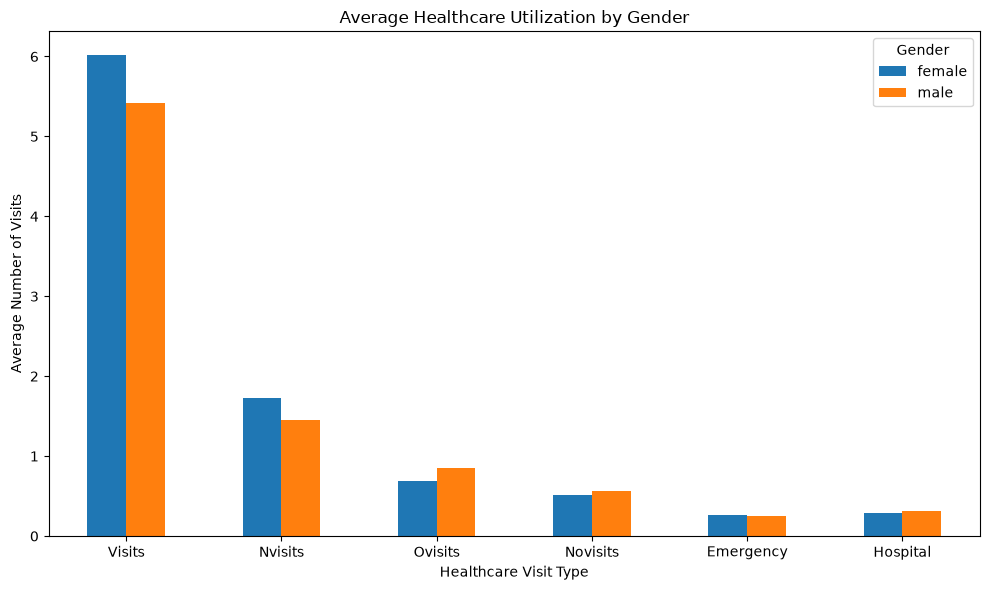

In [9]:
# Transpose the table so the healthcare visit types
# appear along the horizontal axis.
visits_by_gender.T.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add a descriptive title and axis labels.
plt.title("Average Healthcare Utilization by Gender")
plt.xlabel("Healthcare Visit Type")
plt.ylabel("Average Number of Visits")

# Keep the visit-type labels horizontal for readability.
plt.xticks(rotation=0)

# Add a descriptive title to the legend.
plt.legend(title="Gender")

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Healthcare Utilization by Gender Findings

The visualization shows differences in average healthcare utilization between female and male individuals across the six healthcare measures.

Females have a higher average number of overall visits at 6.01 compared with 5.42 for males. Females also have higher average nvisits at 1.73 compared with 1.45 for males.

Males have slightly higher average ovisits at 0.85 compared with 0.68 for females and slightly higher novisits at 0.57 compared with 0.51. Average hospital utilization is also slightly higher for males at 0.31 compared with 0.29 for females.

Emergency utilization is very similar between the two groups, averaging 0.27 for females and 0.25 for males.

Overall, the visualization shows that healthcare utilization differs somewhat by gender, although the direction of the difference depends on the type of healthcare service. These results are descriptive and do not establish that gender causes the observed differences.

## 8. Healthcare Utilization by Employment Status

Average healthcare utilization will be compared between employed and unemployed individuals across the six healthcare visit measures.

A grouped bar chart will be used to visualize differences in overall visits, nvisits, ovisits, novisits, emergency visits, and hospital visits according to employment status.

In [10]:
# Group the dataset by employment status and calculate
# the average for each healthcare utilization variable.
visits_by_employment = df.groupby("employed")[visit_columns].mean()

# Give the row index a descriptive label.
visits_by_employment.index.name = "Employment Status"

# Rename the columns for a cleaner presentation.
visits_by_employment.columns = [
    "Visits",
    "Nvisits",
    "Ovisits",
    "Novisits",
    "Emergency",
    "Hospital"
]

# Display the averages rounded to two decimal places.
visits_by_employment.style.format("{:,.2f}")

,Visits,Nvisits,Ovisits,Novisits,Emergency,Hospital
Employment Status,,,,,,
no,5.81,1.64,0.79,0.55,0.27,0.30
yes,5.49,1.43,0.44,0.42,0.22,0.23


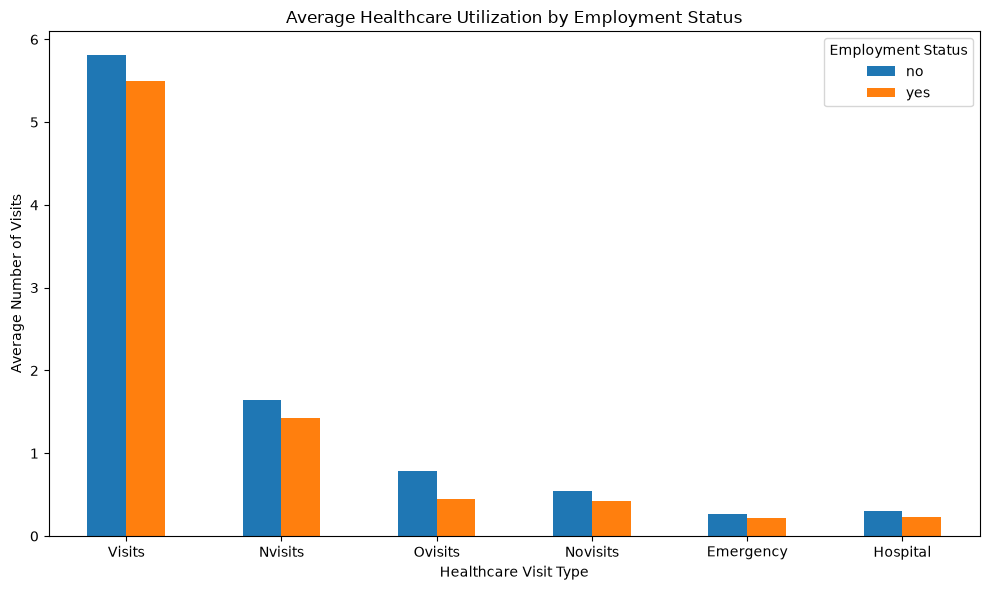

In [11]:
# Transpose the table so the healthcare visit types
# appear along the horizontal axis.
visits_by_employment.T.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add a descriptive title and axis labels.
plt.title("Average Healthcare Utilization by Employment Status")
plt.xlabel("Healthcare Visit Type")
plt.ylabel("Average Number of Visits")

# Keep the visit-type labels horizontal for readability.
plt.xticks(rotation=0)

# Add a descriptive title to the legend.
plt.legend(title="Employment Status")

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Healthcare Utilization by Employment Status Findings

The visualization shows that individuals who are not employed have higher average healthcare utilization across all six healthcare measures compared with employed individuals.

Individuals who are not employed average 5.81 overall visits compared with 5.49 among employed individuals. They also have higher average nvisits at 1.64 compared with 1.43 and higher average ovisits at 0.79 compared with 0.44.

The same pattern appears for novisits, emergency visits, and hospital visits. Individuals who are not employed average 0.55 novisits, 0.27 emergency visits, and 0.30 hospital visits, compared with 0.42, 0.22, and 0.23 respectively among employed individuals.

Overall, the visualization indicates an association between employment status and healthcare utilization, with the non-employed group showing greater average utilization across all six measures. These descriptive results do not establish that employment status causes the observed differences.

## 9. Insurance and Medicaid Utilization

Healthcare utilization will be examined according to insurance and Medicaid coverage.

These visualizations will compare average healthcare utilization across the six visit measures to identify differences in utilization patterns between individuals with and without insurance or Medicaid coverage.

### Healthcare Utilization by Insurance Status

In [12]:
# Group the dataset by insurance status and calculate
# the average for each healthcare utilization variable.
visits_by_insurance = df.groupby("insurance")[visit_columns].mean()

# Give the row index a descriptive label.
visits_by_insurance.index.name = "Insurance Status"

# Rename the columns for a cleaner presentation.
visits_by_insurance.columns = [
    "Visits",
    "Nvisits",
    "Ovisits",
    "Novisits",
    "Emergency",
    "Hospital"
]

# Display the averages rounded to two decimal places.
visits_by_insurance.style.format("{:,.2f}")

,Visits,Nvisits,Ovisits,Novisits,Emergency,Hospital
Insurance Status,,,,,,
no,4.91,0.93,1.06,0.44,0.33,0.31
yes,6.02,1.81,0.66,0.57,0.24,0.29


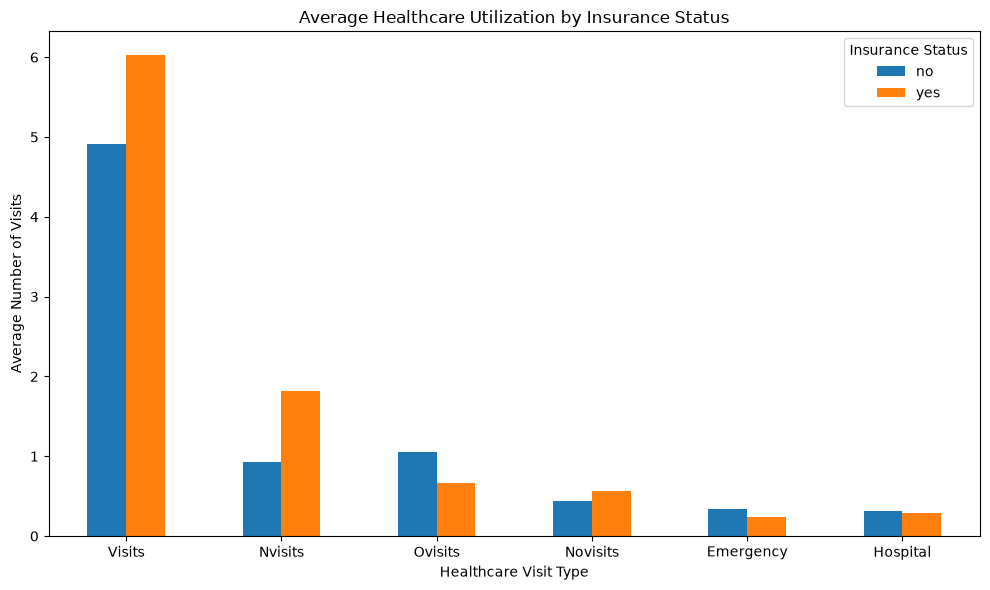

In [13]:
# Transpose the table so the healthcare visit types
# appear along the horizontal axis.
visits_by_insurance.T.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add a descriptive title and axis labels.
plt.title("Average Healthcare Utilization by Insurance Status")
plt.xlabel("Healthcare Visit Type")
plt.ylabel("Average Number of Visits")

# Keep the visit-type labels horizontal for readability.
plt.xticks(rotation=0)

# Add a descriptive title to the legend.
plt.legend(title="Insurance Status")

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Healthcare Utilization by Insurance Status Findings

The visualization shows that healthcare utilization differs by insurance status, although the direction of the difference varies across healthcare services.

Insured individuals have a higher average number of overall visits at 6.02 compared with 4.91 among uninsured individuals. Insured individuals also have higher average nvisits at 1.81 compared with 0.93 and higher average novisits at 0.57 compared with 0.44.

In contrast, uninsured individuals have higher average ovisits at 1.06 compared with 0.66 among insured individuals. Uninsured individuals also have higher average emergency utilization at 0.33 compared with 0.24 and slightly higher hospital utilization at 0.31 compared with 0.29.

Overall, insurance status is associated with different patterns of healthcare utilization rather than a consistent increase or decrease across every healthcare measure. These descriptive results do not establish that insurance status causes the observed differences.

### Healthcare Utilization by Medicaid Status

Average healthcare utilization will also be compared between individuals with and without Medicaid coverage.

This analysis provides another view of how healthcare coverage is associated with utilization across the six healthcare visit measures.

In [14]:
# Group the dataset by Medicaid status and calculate
# the average for each healthcare utilization variable.
visits_by_medicaid = df.groupby("medicaid")[visit_columns].mean()

# Give the row index a descriptive label.
visits_by_medicaid.index.name = "Medicaid Status"

# Rename the columns for a cleaner presentation.
visits_by_medicaid.columns = [
    "Visits",
    "Nvisits",
    "Ovisits",
    "Novisits",
    "Emergency",
    "Hospital"
]

# Display the averages rounded to two decimal places.
visits_by_medicaid.style.format("{:,.2f}")

,Visits,Nvisits,Ovisits,Novisits,Emergency,Hospital
Medicaid Status,,,,,,
no,5.68,1.65,0.73,0.53,0.25,0.28
yes,6.71,1.26,1.01,0.55,0.44,0.42


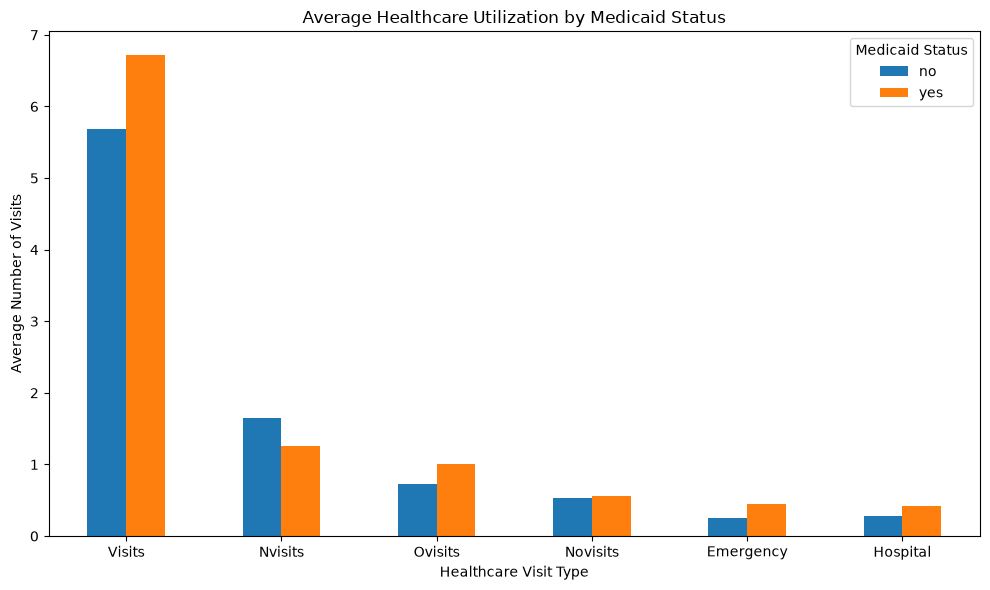

In [15]:
# Transpose the table so the healthcare visit types
# appear along the horizontal axis.
visits_by_medicaid.T.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add a descriptive title and axis labels.
plt.title("Average Healthcare Utilization by Medicaid Status")
plt.xlabel("Healthcare Visit Type")
plt.ylabel("Average Number of Visits")

# Keep the visit-type labels horizontal for readability.
plt.xticks(rotation=0)

# Add a descriptive title to the legend.
plt.legend(title="Medicaid Status")

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Healthcare Utilization by Medicaid Status Findings

The visualization shows differences in average healthcare utilization between individuals with and without Medicaid coverage.

Individuals with Medicaid have a higher average number of overall visits at 6.71 compared with 5.68 among individuals without Medicaid. Medicaid recipients also have higher average ovisits at 1.01 compared with 0.73, higher emergency utilization at 0.44 compared with 0.25, and higher hospital utilization at 0.42 compared with 0.28.

Average novisits are similar between the groups, at 0.55 for individuals with Medicaid and 0.53 for individuals without Medicaid.

The primary exception to the overall pattern is nvisits. Individuals without Medicaid average 1.65 nvisits compared with 1.26 among individuals with Medicaid.

Overall, individuals with Medicaid show higher average utilization across most of the healthcare measures examined. These descriptive results demonstrate an association between Medicaid status and healthcare utilization but do not establish that Medicaid coverage causes the observed differences.

## 10. Age and Gender Distribution

The number of female and male individuals at each age will be visualized to examine the age distribution of the dataset.

A line chart will be used because age is an ordered numerical variable. This allows changes in the number of observations across increasing ages to be viewed more clearly than in the detailed distribution table.

In [16]:
# Create a cross-tabulation counting the number
# of individuals at each age separated by gender.
age_gender_counts = pd.crosstab(
    df["age"],
    df["gender"]
)

# Give the rows and columns descriptive labels.
age_gender_counts.index.name = "Age"
age_gender_counts.columns.name = "Gender"

# Display the first ten rows to verify the analysis.
age_gender_counts.head(10)

Gender,female,male
Age,,
66.0,190,160
67.0,198,140
68.0,173,123
69.0,162,131
70.0,174,117
71.0,154,115
72.0,158,123
73.0,156,97
74.0,141,108


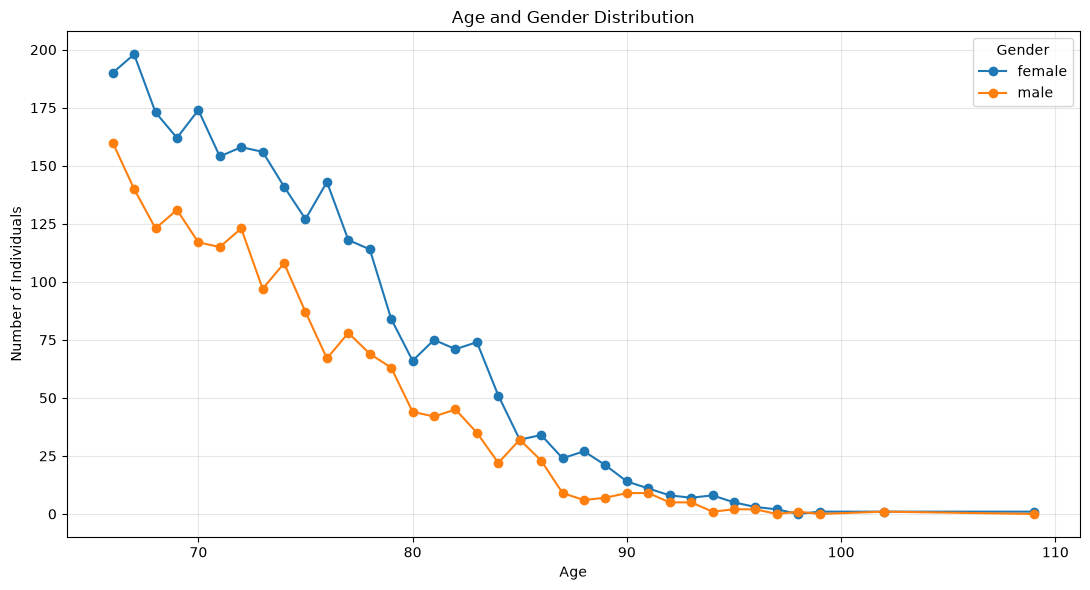

In [17]:
# Create a line chart showing the number of female and male
# individuals represented at each age.
age_gender_counts.plot(
    kind="line",
    figsize=(11, 6),
    marker="o"
)

# Add a descriptive title and axis labels.
plt.title("Age and Gender Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Individuals")

# Add a descriptive title to the legend.
plt.legend(title="Gender")

# Add a light grid to make the values easier to compare.
plt.grid(alpha=0.3)

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Age and Gender Distribution Findings

The visualization shows that the dataset contains more individuals at the younger end of the represented age range and that the number of observations generally decreases as age increases.

Females outnumber males across most ages in the dataset. At age 66, there are 190 females and 160 males, while age 67 contains 198 females and 140 males.

The number of individuals declines substantially among the older age groups. The oldest ages contain very few observations, which is important when interpreting statistics calculated for those groups because individual records can have a greater influence on the results.

Overall, the line chart makes the age distribution much clearer than the detailed table and shows both the declining number of observations at older ages and the larger representation of females across most of the age range.

## 11. Income Distribution by Gender

Mean and median income will be compared between female and male individuals.

Both measures are included because the earlier analysis showed that income is right-skewed. Comparing mean and median income helps demonstrate how higher income observations influence the average.

In [18]:
# Group the dataset by gender and calculate
# mean and median income for each group.
income_by_gender = df.groupby("gender")["income"].agg(
    Mean="mean",
    Median="median"
)

# Give the row index a descriptive label.
income_by_gender.index.name = "Gender"

# Rename the columns for presentation.
income_by_gender.columns = [
    "Mean Income",
    "Median Income"
]

# Display the income statistics as currency.
income_by_gender.style.format({
    "Mean Income": "${:,.2f}",
    "Median Income": "${:,.2f}"
})

,Mean Income,Median Income
Gender,,
female,"$22,493.48","$14,160.00"
male,"$29,377.16","$20,574.00"


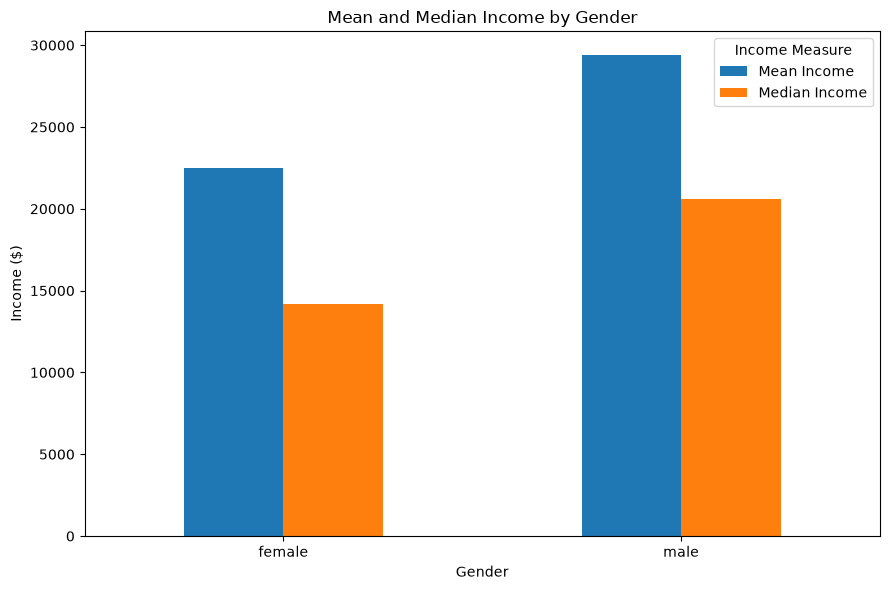

In [19]:
# Create a grouped bar chart comparing mean
# and median income by gender.
income_by_gender.plot(
    kind="bar",
    figsize=(9, 6)
)

# Add a descriptive title and axis labels.
plt.title("Mean and Median Income by Gender")
plt.xlabel("Gender")
plt.ylabel("Income ($)")

# Keep the gender labels horizontal for readability.
plt.xticks(rotation=0)

# Add a descriptive title to the legend.
plt.legend(title="Income Measure")

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Income Distribution by Gender Findings

The visualization shows that both mean and median income are higher among male individuals than female individuals in the dataset.

Male individuals have a mean income of $29,377.16 compared with $22,493.48 for female individuals. Median income shows the same pattern, with males at $20,574.00 compared with $14,160.00 for females.

For both genders, mean income is substantially higher than median income. This difference is consistent with the right-skewed income distribution identified during the earlier analysis, where relatively high income observations increase the mean.

Overall, the visualization demonstrates a descriptive income difference between males and females in this dataset. It does not establish that gender causes the observed income difference.

## 12. Regional Income Distribution

Mean and median income will be compared across the four geographic regions represented in the dataset.

Both measures will be visualized because the income distribution is right-skewed. Comparing the mean and median provides a clearer picture of typical regional income than relying on the mean alone.

In [20]:
# Group the dataset by region and calculate
# mean and median income for each region.
income_by_region = df.groupby("region")["income"].agg(
    Mean="mean",
    Median="median"
)

# Give the row index a descriptive label.
income_by_region.index.name = "Region"

# Rename the columns for presentation.
income_by_region.columns = [
    "Mean Income",
    "Median Income"
]

# Display the income statistics as currency.
income_by_region.style.format({
    "Mean Income": "${:,.2f}",
    "Median Income": "${:,.2f}"
})

,Mean Income,Median Income
Region,,
midwest,"$25,136.34","$17,875.00"
northeast,"$26,797.09","$17,413.00"
other,"$21,662.84","$14,220.00"
west,"$31,165.05","$20,656.00"


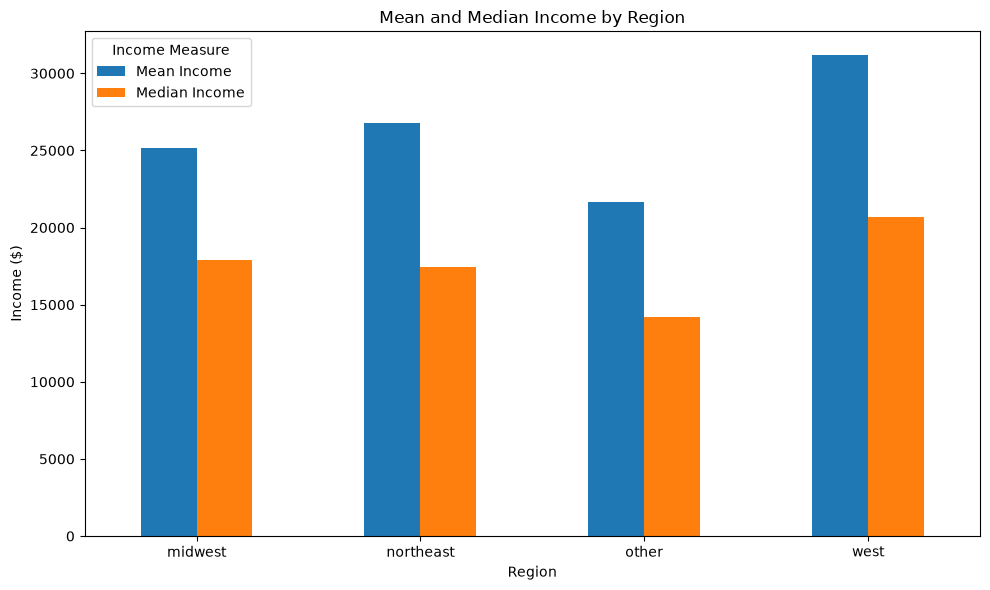

In [21]:
# Create a grouped bar chart comparing mean
# and median income across geographic regions.
income_by_region.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add a descriptive title and axis labels.
plt.title("Mean and Median Income by Region")
plt.xlabel("Region")
plt.ylabel("Income ($)")

# Keep the region labels horizontal for readability.
plt.xticks(rotation=0)

# Add a descriptive title to the legend.
plt.legend(title="Income Measure")

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

## 13. Age-wise Income Analysis

Mean and median income will be analyzed across the ages represented in the dataset.

A line chart will be used because age is an ordered numerical variable. This visualization will help show how income changes across age while also allowing the mean and median income patterns to be compared.

In [22]:
# Group the dataset by age and calculate
# mean and median income for each age.
income_by_age = df.groupby("age")["income"].agg(
    Mean="mean",
    Median="median"
)

# Give the row index a descriptive label.
income_by_age.index.name = "Age"

# Rename the columns for presentation.
income_by_age.columns = [
    "Mean Income",
    "Median Income"
]

# Display the first ten ages to verify the analysis.
income_by_age.head(10).style.format({
    "Mean Income": "${:,.2f}",
    "Median Income": "${:,.2f}"
})

,Mean Income,Median Income
Age,,
66.000000,"$30,425.64","$20,240.00"
67.000000,"$30,340.23","$20,024.00"
68.000000,"$25,942.23","$20,060.50"
69.000000,"$23,824.16","$19,000.00"
70.000000,"$25,907.28","$18,267.00"
71.000000,"$25,815.96","$18,446.00"
72.000000,"$25,810.44","$19,855.58"
73.000000,"$27,127.46","$15,020.00"
74.000000,"$27,138.55","$16,233.00"


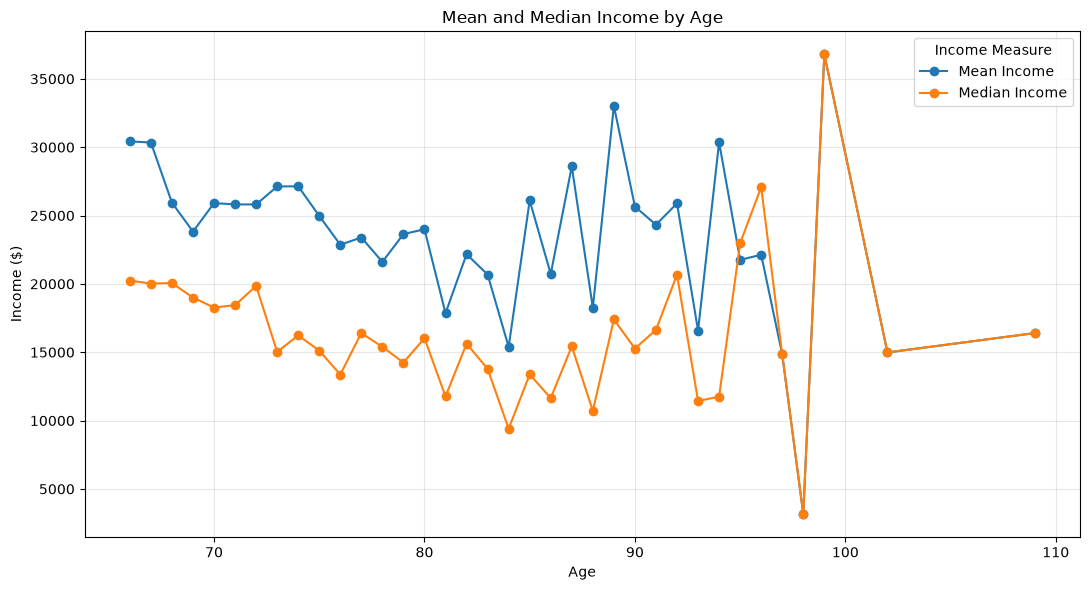

In [23]:
# Create a line chart showing mean and median
# income across all ages in the dataset.
income_by_age.plot(
    kind="line",
    figsize=(11, 6),
    marker="o"
)

# Add a descriptive title and axis labels.
plt.title("Mean and Median Income by Age")
plt.xlabel("Age")
plt.ylabel("Income ($)")

# Add a descriptive title to the legend.
plt.legend(title="Income Measure")

# Add a light grid to make values easier to compare.
plt.grid(alpha=0.3)

# Adjust spacing so chart elements are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Age-wise Income Analysis Findings

The visualization shows that income varies considerably across age and does not follow a consistent year-by-year increase or decrease.

At the younger end of the dataset, individuals age 66 have a mean income of $30,425.64 and a median income of $20,240.00, while individuals age 67 have a similar mean income of $30,340.23 and median income of $20,024.00.

Mean income is higher than median income across many ages, which is consistent with the right-skewed income distribution identified during the earlier analysis.

Income generally becomes more variable among the oldest age groups. These ages contain substantially fewer individuals, so their mean and median income values are more sensitive to individual observations. For example, some of the oldest ages contain only one or two individuals.

Overall, the visualization suggests that income varies with age but does not show a simple linear relationship. The smaller group sizes among the oldest individuals should be considered when interpreting fluctuations in income at those ages.

## 14. Correlation Analysis

Correlation analysis will be used to examine the relationships among the numerical variables in the healthcare dataset.

A correlation coefficient measures the direction and strength of the relationship between two numerical variables. Correlation values range from -1 to +1.

- A value near **+1** indicates a strong positive relationship.
- A value near **-1** indicates a strong negative relationship.
- A value near **0** indicates little or no linear relationship.

Correlation identifies statistical relationships between variables but does not establish that one variable causes changes in another.

In [24]:
# Select only the numerical variables from the dataset.
numeric_df = df.select_dtypes(include="number")

# Display the numerical column names that will
# be included in the correlation analysis.
print("Numerical Variables:")
print(numeric_df.columns.tolist())

Numerical Variables:
['visits', 'nvisits', 'ovisits', 'novisits', 'emergency', 'hospital', 'chronic', 'age', 'school', 'income']


### Correlation Matrix

A correlation matrix will be calculated for the numerical variables in the dataset.

Each cell in the matrix represents the Pearson correlation coefficient between two variables. The values range from -1 to +1, with the sign indicating the direction of the relationship and the magnitude indicating the strength of the linear relationship.

In [25]:
# Calculate the Pearson correlation coefficient
# between every pair of numerical variables.
correlation_matrix = numeric_df.corr()

# Display the correlation coefficients rounded
# to two decimal places for easier interpretation.
correlation_matrix.round(2)

,visits,nvisits,ovisits,novisits,emergency,hospital,chronic,age,school,income
visits,1.00,0.23,0.07,0.08,0.16,0.24,0.26,0.00,0.06,-0.00
nvisits,0.23,1.00,0.00,0.04,0.05,0.05,0.04,-0.04,0.09,0.01
ovisits,0.07,0.00,1.00,0.47,0.07,0.11,0.10,-0.04,-0.01,-0.00
novisits,0.08,0.04,0.47,1.00,0.02,0.07,0.04,-0.03,-0.01,-0.01
emergency,0.16,0.05,0.07,0.02,1.00,0.48,0.20,0.06,-0.07,-0.03
hospital,0.24,0.05,0.11,0.07,0.48,1.00,0.23,0.07,-0.04,-0.01
chronic,0.26,0.04,0.10,0.04,0.20,0.23,1.00,0.10,-0.07,-0.05
age,0.00,-0.04,-0.04,-0.03,0.06,0.07,0.10,1.00,-0.14,-0.07
school,0.06,0.09,-0.01,-0.01,-0.07,-0.04,-0.07,-0.14,1.00,0.26
income,-0.00,0.01,-0.00,-0.01,-0.03,-0.01,-0.05,-0.07,0.26,1.00


### Correlation Analysis Findings

The correlation matrix shows that most numerical variables have weak linear relationships, although several healthcare utilization variables have moderate positive correlations.

The strongest positive correlation is between emergency visits and hospital visits at 0.48. This indicates that individuals with higher emergency utilization also tend to have higher hospital utilization.

Ovisits and novisits have a similar positive correlation of 0.47, indicating that these two healthcare utilization measures tend to increase together.

The number of chronic conditions has a positive correlation of 0.26 with overall healthcare visits. This suggests that individuals with more chronic conditions tend to have somewhat greater overall healthcare utilization.

Schooling and income also have a positive correlation of 0.26, indicating that greater years of schooling are associated with higher income within the dataset.

Most other correlations are relatively weak. The largest negative correlation is between age and years of schooling at -0.14. Age and income have a weak negative correlation of -0.07.

Overall, the correlation analysis identifies several relationships among healthcare utilization and socioeconomic variables, but none of the non-self correlations are extremely strong. These correlations describe linear associations within the dataset and do not establish causal relationships.

### Correlation Matrix Visualization

A correlation heatmap will be created to make the relationships among the numerical variables easier to identify visually.

The visualization represents the correlation coefficients from -1 to +1 and displays the numerical correlation value inside each cell.

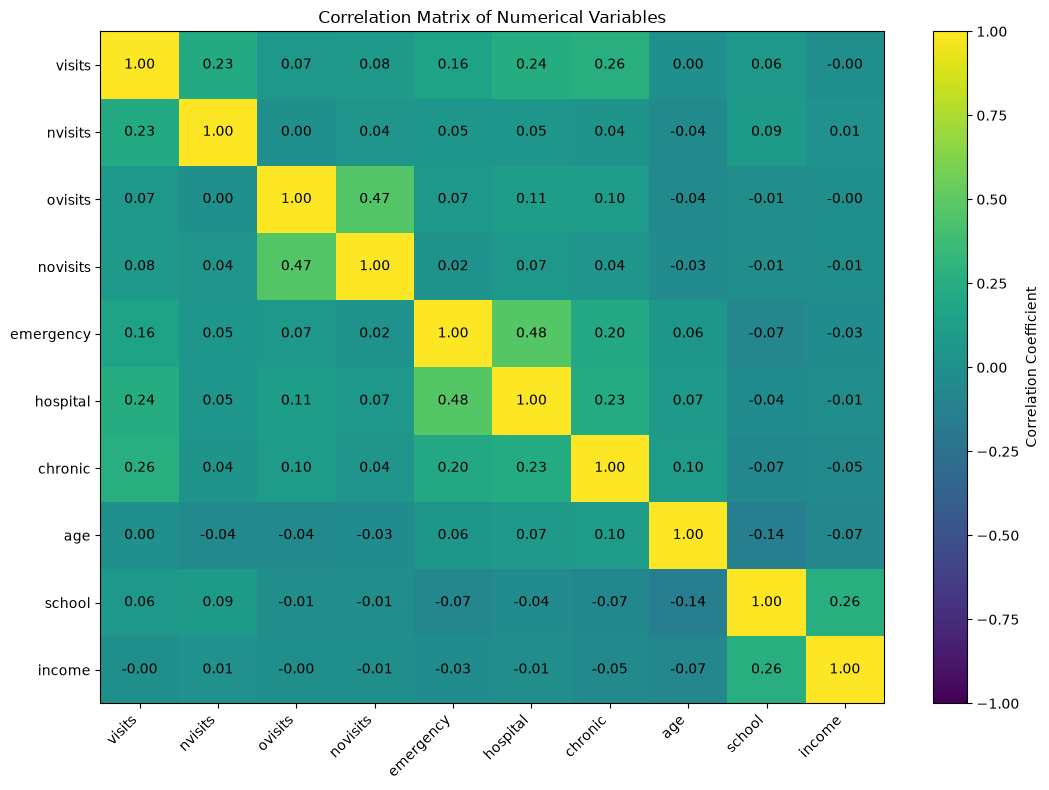

In [26]:
# Create a figure for the correlation heatmap.
fig, ax = plt.subplots(figsize=(11, 8))

# Display the correlation matrix as a heatmap.
# vmin and vmax keep the correlation scale fixed from -1 to +1.
heatmap = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

# Add the numerical variable names to both axes.
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlation_matrix.index)

# Display each correlation coefficient inside its cell.
for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        ax.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

# Add a color scale showing the correlation coefficient.
colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Correlation Coefficient")

# Add a descriptive chart title.
ax.set_title("Correlation Matrix of Numerical Variables")

# Adjust spacing so labels are not cut off.
plt.tight_layout()

# Display the completed visualization.
plt.show()

### Correlation Heatmap Findings

The correlation heatmap provides a visual summary of the linear relationships among the numerical variables in the dataset.

The strongest positive relationship outside the diagonal is between emergency visits and hospital visits, with a correlation coefficient of 0.48. Ovisits and novisits also show a notable positive correlation of 0.47.

Overall healthcare visits have a positive correlation of 0.26 with the number of chronic conditions, indicating that individuals with more chronic conditions tend to have somewhat greater healthcare utilization. Years of schooling and income also have a positive correlation of 0.26.

Most of the remaining relationships are weak. The strongest negative relationship is between age and years of schooling at -0.14, while age and income have a weak negative correlation of -0.07.

Overall, the heatmap confirms that the dataset contains several meaningful positive associations, particularly among healthcare utilization variables, but no extremely strong linear relationships between different variables. Correlation represents association and does not establish causation.

## 15. Final Session 4 Findings and Conclusions

Session 4 used Matplotlib and Pandas visualization capabilities to present the healthcare, demographic, socioeconomic, and correlation analyses developed during the previous capstone sessions.

### Health Status and Region

Average health was the most frequently reported health category across all four geographic regions. The Other region contained the largest raw number of observations. Because the regional sample sizes differ, these raw counts should not be interpreted as evidence that one region has better or worse health.

Healthcare utilization showed a clearer relationship with health status. Individuals reporting poor health had the highest average number of healthcare visits in every region, while individuals reporting excellent health consistently had the lowest average utilization.

### Healthcare Utilization

Healthcare utilization differed across demographic and coverage characteristics.

Female individuals had higher average overall visits and nvisits than male individuals, while males had slightly higher averages for several other utilization measures.

Individuals who were not employed showed higher average utilization across all six healthcare measures compared with employed individuals.

Insurance status showed a mixed utilization pattern. Insured individuals had higher overall visits, nvisits, and novisits, while uninsured individuals had higher ovisits, emergency visits, and slightly higher hospital utilization.

Individuals with Medicaid had higher average utilization across most healthcare measures, including overall visits, ovisits, emergency visits, and hospital visits. Nvisits were higher among individuals without Medicaid.

### Age and Gender

The dataset contains more observations among the younger portion of the represented age range, and the number of individuals generally decreases as age increases. Females outnumber males across most ages.

The oldest age groups contain relatively few observations. Statistics for these groups should therefore be interpreted carefully because individual observations can have a larger effect on calculated averages.

### Income

Male individuals had higher mean and median income than female individuals in the dataset.

Regional differences were also observed. The West had the highest mean and median income, while the Other region had the lowest.

Mean income exceeded median income across gender and regional groups, reinforcing the earlier finding that the income distribution is right-skewed.

Age-wise income varied considerably and did not demonstrate a simple linear increase or decrease with age. Income estimates among the oldest ages were more variable because those age groups contained relatively few observations.

### Correlation Analysis

The strongest positive numerical correlations were between emergency and hospital utilization (0.48) and between ovisits and novisits (0.47).

Overall healthcare visits had a positive correlation of 0.26 with chronic conditions, suggesting that individuals with more chronic conditions tend to have somewhat greater healthcare utilization.

Years of schooling and income also had a positive correlation of 0.26.

Most other numerical relationships were weak, and no non-self correlation approached a perfect positive or negative relationship.

### Overall Conclusion

The visual analysis demonstrates that healthcare utilization is associated with health status, demographic characteristics, employment, insurance coverage, Medicaid coverage, and chronic conditions. Income also varies across gender, region, and age.

The visualizations make the patterns identified during the earlier statistical analysis easier to interpret and communicate. The findings describe associations within the NSMES1988 dataset and should not be interpreted as evidence of causal relationships.